# Doctor-week XGBoost Model 

In [17]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyarrow.parquet as pq
import re

In [18]:
#Import silver dataset

table = pq.read_table(r"C:\Users\omarl\Downloads\silver_layer_longitudinal.parquet")
df = table.to_pandas()

In [19]:
df_week = df[df["ATSEG"].notna()].copy()
df_week = df_week.sort_values(["NUEVO_ID", "WEEK_ID"]).reset_index(drop=True)

id_col = "NUEVO_ID"
target_col = "ATSEG"

In [20]:
drop_cols = [
    "ATSEG", "ATSEG_RAW", "ATSEG_HCP", "IS_LABELED_HCP",
    "NUEVO_ID", "HCP_FOLD"
]

feature_cols_week = [c for c in df_week.columns if c not in drop_cols]

X_week = df_week[feature_cols_week].copy()
y_week = df_week[target_col].copy()
groups = df_week[id_col].copy()

In [21]:
extra_drop = ["SPECIALTY_GROUP", "STATE_GROUP", "AGE_RANGE_GROUP", "YEAR_QTR"]
X_week = X_week.drop(columns=[c for c in extra_drop if c in X_week.columns])

In [22]:
def clean_feature_name(col):
    col = str(col)
    for ch in ["[", "]", "<", ">", "(", ")", ",", " ", "/", "-"]:
        col = col.replace(ch, "_")
    col = re.sub(r"__+", "_", col)
    return col.strip("_")

X_week.columns = [clean_feature_name(c) for c in X_week.columns]

In [23]:
from sklearn.preprocessing import LabelEncoder

le_week = LabelEncoder()
y_week_encoded = le_week.fit_transform(y_week)

print(le_week.classes_)

['SEG_A' 'SEG_B' 'SEG_C']


In [24]:
X_week["year"] = df_week["WEEK_ID"].dt.year
X_week["week"] = df_week["WEEK_ID"].dt.isocalendar().week.astype(int)

X_week = X_week.drop(columns=["WEEK_ID"])

In [25]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(gss.split(X_week, y_week_encoded, groups=groups))

X_train_w = X_week.iloc[train_idx]
X_test_w = X_week.iloc[test_idx]

y_train_w = y_week_encoded[train_idx]
y_test_w = y_week_encoded[test_idx]

groups_train = groups.iloc[train_idx]
groups_test = groups.iloc[test_idx]

print("Train rows:", X_train_w.shape)
print("Test rows:", X_test_w.shape)
print("Overlap doctors:", set(groups_train).intersection(set(groups_test)))

Train rows: (818634, 67)
Test rows: (204680, 67)
Overlap doctors: set()


In [26]:
from sklearn.utils.class_weight import compute_sample_weight

sample_weights_w = compute_sample_weight(
    class_weight="balanced",
    y=y_train_w
)

In [27]:
X_week.dtypes.value_counts()

float32    42
int8       21
int16       2
int32       2
Name: count, dtype: int64

In [28]:
from xgboost import XGBClassifier

xgb_week = XGBClassifier(
    objective="multi:softprob",
    num_class=len(le_week.classes_),
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="mlogloss"
)

xgb_week.fit(
    X_train_w,
    y_train_w,
    sample_weight=sample_weights_w
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_class=3, num_parallel_tree=None, ...)

In [29]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import pandas as pd

y_pred_w = xgb_week.predict(X_test_w)

print("Doctor-week XGB Accuracy:", accuracy_score(y_test_w, y_pred_w))
print("Doctor-week XGB Macro F1:", f1_score(y_test_w, y_pred_w, average="macro"))
print("Doctor-week XGB Weighted F1:", f1_score(y_test_w, y_pred_w, average="weighted"))

print(classification_report(y_test_w, y_pred_w, target_names=le_week.classes_))

Doctor-week XGB Accuracy: 0.5928180574555404
Doctor-week XGB Macro F1: 0.5279268510139582
Doctor-week XGB Weighted F1: 0.5996964296775026
              precision    recall  f1-score   support

       SEG_A       0.76      0.72      0.74    113176
       SEG_B       0.51      0.40      0.45     56330
       SEG_C       0.33      0.50      0.40     35174

    accuracy                           0.59    204680
   macro avg       0.53      0.54      0.53    204680
weighted avg       0.62      0.59      0.60    204680



,SEG_A,SEG_B,SEG_C
SEG_A,81144,13092,18940
SEG_B,16407,22466,17457
SEG_C,9285,8161,17728


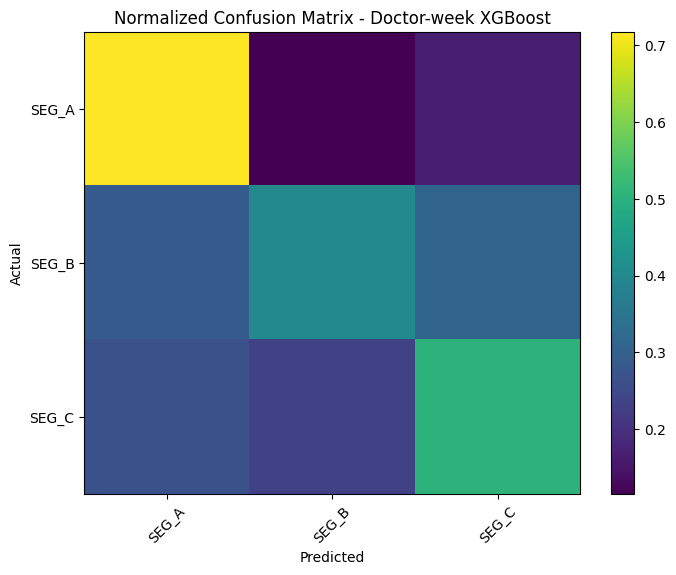

In [30]:
cm_w = confusion_matrix(y_test_w, y_pred_w)
cm_w_df = pd.DataFrame(cm_w, index=le_week.classes_, columns=le_week.classes_)
display(cm_w_df)

cm_w_norm = cm_w / cm_w.sum(axis=1, keepdims=True)

plt.figure(figsize=(8,6))
plt.imshow(cm_w_norm, aspect="auto")
plt.colorbar()
plt.xticks(range(len(le_week.classes_)), le_week.classes_, rotation=45)
plt.yticks(range(len(le_week.classes_)), le_week.classes_)
plt.title("Normalized Confusion Matrix - Doctor-week XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()